<a href="https://colab.research.google.com/github/Hemanth14311/Final-year-Project-Hemanth/blob/main/hate_complete_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# ==========================================
# Load datasets
# ==========================================
train_df = pd.read_csv('/content/train.csv.zip')
test_df = pd.read_csv('/content/test.csv.zip')

print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

# ==========================================
# Target columns
# ==========================================
target_columns = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

# Create binary label: toxic or non-toxic
train_df['is_toxic'] = train_df[target_columns].max(axis=1)

# ==========================================
# Target columns
# ==========================================
target_columns = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

# Create binary label: toxic or non-toxic
train_df['is_toxic'] = train_df[target_columns].max(axis=1)

Training dataset shape: (159571, 8)
Test dataset shape: (153164, 2)


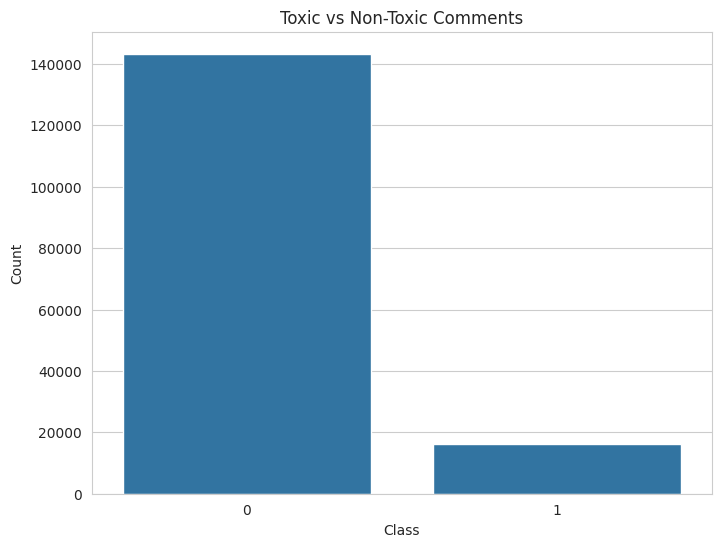

Text cleaning completed.


In [ ]:
# ==========================================
# Data distribution
# ==========================================
plt.figure(figsize=(8, 6))
sns.countplot(x='is_toxic', data=train_df)
plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ==========================================
# Text cleaning function
# ==========================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

# Apply text cleaning
train_df['clean_text'] = train_df['comment_text'].apply(lambda x: clean_text(str(x)))
test_df['clean_text'] = test_df['comment_text'].apply(lambda x: clean_text(str(x)))

print("Text cleaning completed.")

In [ ]:
# ==========================================
# Train-validation split
# ==========================================
X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean_text'],
    train_df['is_toxic'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['is_toxic']
)


In [ ]:
# ==========================================
# TF-IDF
# ==========================================
tfidf = TfidfVectorizer(stop_words='english')

# ==========================================
# Logistic Regression + GridSearch
# ==========================================
log_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', LogisticRegression())
])

log_params = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__C': [0.1, 1, 10],
    'model__max_iter': [200]
}

log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training Logistic Regression with hyperparameter tuning...")
log_grid.fit(X_train, y_train)

Training Logistic Regression with hyperparameter tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'model__max_iter': [200],
                         'tfidf__max_features': [5000, 10000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=1)

In [ ]:
# ==========================================
# Random Forest + GridSearch
# ==========================================
rf_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', RandomForestClassifier(random_state=42))
])

rf_params = {
    'tfidf__max_features': [5000],
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest with hyperparameter tuning...")
rf_grid.fit(X_train, y_train)

Training Random Forest with hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200],
                         'tfidf__max_features': [5000]},
             scoring='accuracy', verbose=1)

In [ ]:
# ==========================================
# SVM + GridSearch
# ==========================================
svm_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', SVC())
])

svm_params = {
    'tfidf__max_features': [5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__C': [0.5, 1, 5],
    'model__kernel': ['linear']
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training SVM with hyperparameter tuning...")
svm_grid.fit(X_train, y_train)

Training SVM with hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.5, 1, 5], 'model__kernel': ['linear'],
                         'tfidf__max_features': [5000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=1)

In [ ]:
# ==========================================
# Best estimators
# ==========================================
best_log = log_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_

print("\nBest Logistic Regression Params:", log_grid.best_params_)
print("Best Random Forest Params:", rf_grid.best_params_)
print("Best SVM Params:", svm_grid.best_params_)



Best Logistic Regression Params: {'model__C': 10, 'model__max_iter': 200, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
Best Random Forest Params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200, 'tfidf__max_features': 5000}
Best SVM Params: {'model__C': 5, 'model__kernel': 'linear', 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}


In [ ]:
# ==========================================
# Predictions
# ==========================================
y_pred_log = best_log.predict(X_val)
y_pred_rf = best_rf.predict(X_val)
y_pred_svm = best_svm.predict(X_val)

In [ ]:
# ==========================================
# Classification Reports
# ==========================================
print("\n========== Logistic Regression Report ==========")
print(classification_report(y_val, y_pred_log))

print("\n========== Random Forest Report ==========")
print(classification_report(y_val, y_pred_rf))

print("\n========== SVM Report ==========")
print(classification_report(y_val, y_pred_svm))


========== Logistic Regression Report ==========
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28670
           1       0.87      0.70      0.77      3245

    accuracy                           0.96     31915
   macro avg       0.92      0.84      0.88     31915
weighted avg       0.96      0.96      0.96     31915


========== Random Forest Report ==========
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     28670
           1       0.84      0.67      0.74      3245

    accuracy                           0.95     31915
   macro avg       0.90      0.83      0.86     31915
weighted avg       0.95      0.95      0.95     31915


========== SVM Report ==========
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28670
           1       0.87      0.67      0.76      3245

    accuracy                           0.96     31915


In [ ]:
# ==========================================
# Store metrics for all models
# ==========================================
results = {
    "Logistic Regression": {
        "accuracy": accuracy_score(y_val, y_pred_log),
        "precision": precision_score(y_val, y_pred_log, average='weighted'),
        "recall": recall_score(y_val, y_pred_log, average='weighted'),
        "f1_score": f1_score(y_val, y_pred_log, average='weighted'),
        "conf_matrix": confusion_matrix(y_val, y_pred_log)
    },
    "Random Forest": {
        "accuracy": accuracy_score(y_val, y_pred_rf),
        "precision": precision_score(y_val, y_pred_rf, average='weighted'),
        "recall": recall_score(y_val, y_pred_rf, average='weighted'),
        "f1_score": f1_score(y_val, y_pred_rf, average='weighted'),
        "conf_matrix": confusion_matrix(y_val, y_pred_rf)
    },
    "SVM": {
        "accuracy": accuracy_score(y_val, y_pred_svm),
        "precision": precision_score(y_val, y_pred_svm, average='weighted'),
        "recall": recall_score(y_val, y_pred_svm, average='weighted'),
        "f1_score": f1_score(y_val, y_pred_svm, average='weighted'),
        "conf_matrix": confusion_matrix(y_val, y_pred_svm)
    }
}

In [ ]:
# ==========================================
# Print metric values
# ==========================================
print("\n========== Model Performance Summary ==========")
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Score : {metrics['f1_score']:.4f}")


========== Model Performance Summary ==========

Logistic Regression
Accuracy : 0.9584
Precision: 0.9564
Recall   : 0.9584
F1 Score : 0.9563

Random Forest
Accuracy : 0.9530
Precision: 0.9504
Recall   : 0.9530
F1 Score : 0.9506

SVM
Accuracy : 0.9561
Precision: 0.9538
Recall   : 0.9561
F1 Score : 0.9535


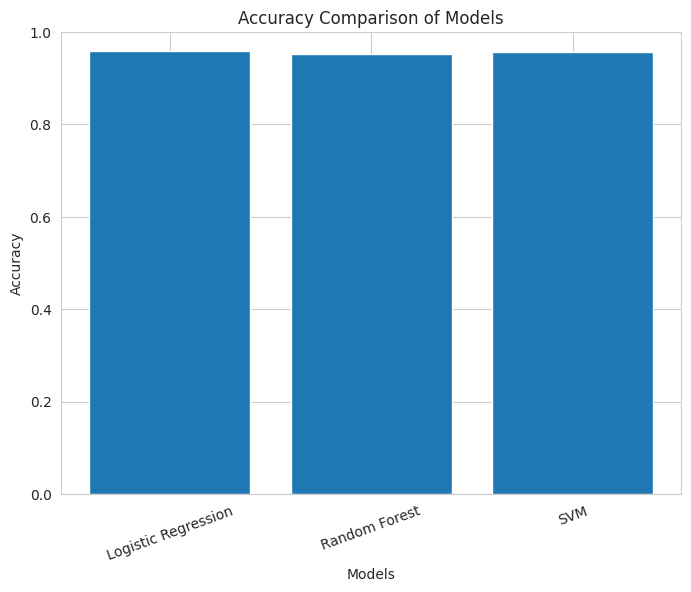

In [ ]:
# ==========================================
# Separate Bar Graph for Accuracy
# ==========================================
model_names = list(results.keys())
accuracy_values = [results[model]["accuracy"] for model in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, accuracy_values)
plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

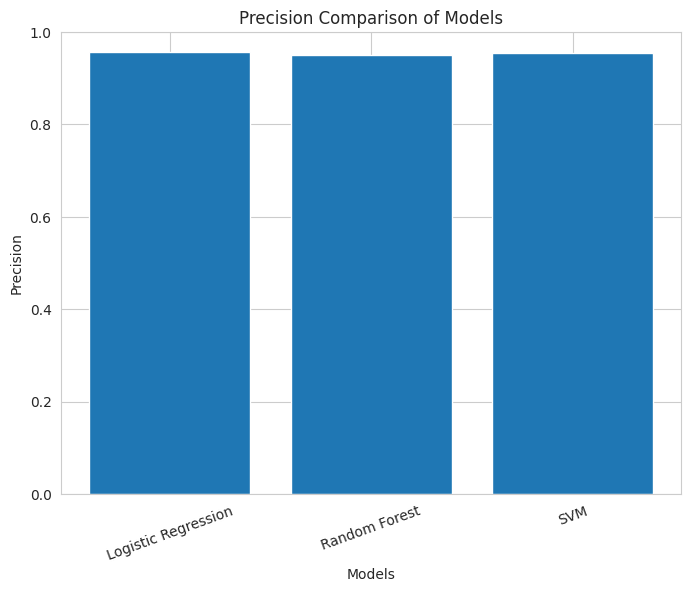

In [ ]:
# ==========================================
# Separate Bar Graph for Precision
# ==========================================
precision_values = [results[model]["precision"] for model in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, precision_values)
plt.title("Precision Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

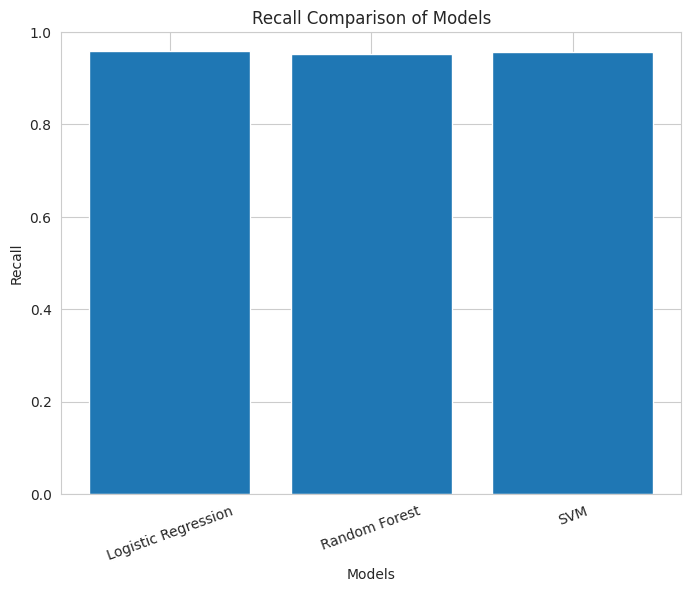

In [ ]:
# ==========================================
# Separate Bar Graph for Recall
# ==========================================
recall_values = [results[model]["recall"] for model in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, recall_values)
plt.title("Recall Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

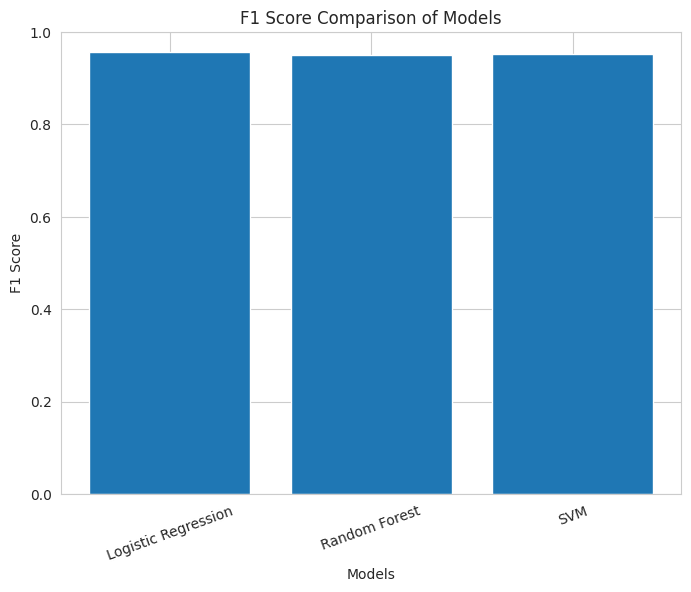

In [ ]:
# ==========================================
# Separate Bar Graph for F1 Score
# ==========================================
f1_values = [results[model]["f1_score"] for model in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, f1_values)
plt.title("F1 Score Comparison of Models")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

<Figure size 600x500 with 0 Axes>

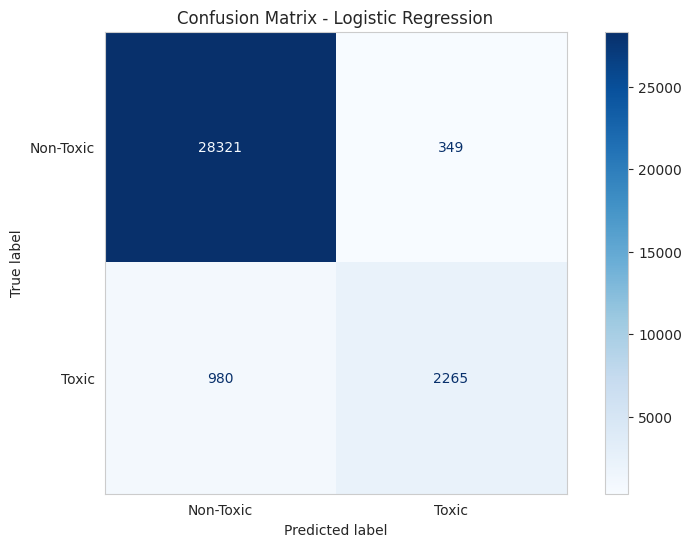

<Figure size 600x500 with 0 Axes>

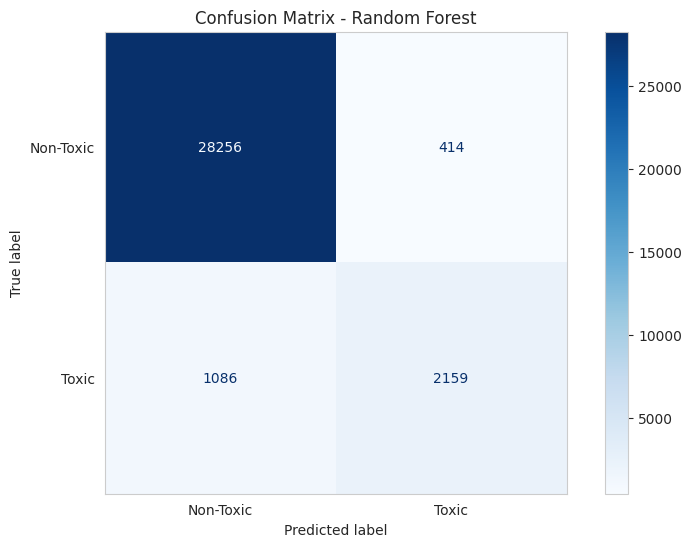

<Figure size 600x500 with 0 Axes>

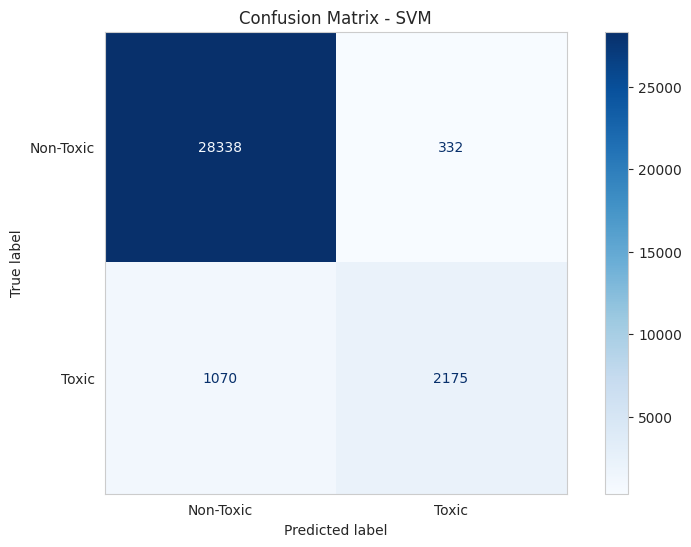

In [ ]:
# ==========================================
# Confusion Matrix for all models
# ==========================================
for model_name, metrics in results.items():
    cm = metrics["conf_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Toxic", "Toxic"])

    plt.figure(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()